In [49]:
import matplotlib.pyplot as plt
import polars as pl

In [35]:
df = pl.read_csv("dataset_mood_smartphone.csv", infer_schema_length=0).with_columns(
    pl.col("time").str.to_datetime("%Y-%m-%d %H:%M:%S%.3f", strict=False),
    pl.col("value").cast(pl.Float64, strict=False),
).with_columns( pl.col("time").dt.date().alias("date"),
    pl.col("time").dt.time().alias("time")).drop("")

In [37]:
df.head(10)

id,time,variable,value,date
str,time,str,f64,date
"""AS14.01""",13:00:00,"""mood""",6.0,2014-02-26
"""AS14.01""",15:00:00,"""mood""",6.0,2014-02-26
"""AS14.01""",18:00:00,"""mood""",6.0,2014-02-26
"""AS14.01""",21:00:00,"""mood""",7.0,2014-02-26
"""AS14.01""",09:00:00,"""mood""",6.0,2014-02-27
"""AS14.01""",12:00:00,"""mood""",6.0,2014-02-27
"""AS14.01""",15:00:00,"""mood""",7.0,2014-02-27
"""AS14.01""",09:00:00,"""mood""",6.0,2014-03-21
"""AS14.01""",11:00:00,"""mood""",6.0,2014-03-21


In [36]:
df.select(pl.col("time", "variable", "value", "date")).describe()

statistic,time,variable,value,date
str,str,str,f64,str
"""count""","""376912""","""376912""",376710.0,"""376912"""
"""null_count""","""0""","""0""",202.0,"""0"""
"""mean""","""14:56:50.210806""",null,40.665313,"""2014-04-15 14:04:26.748737"""
"""std""",null,null,273.726007,null
"""min""","""00:00:00""","""activity""",-82798.871,"""2014-02-17"""
"""25%""","""11:25:11.648000""",null,2.025,"""2014-04-03"""
"""50%""","""15:21:00.812000""",null,7.029,"""2014-04-15"""
"""75%""","""19:17:59.874000""",null,29.356,"""2014-04-27"""
"""max""","""23:59:59.946000""","""sms""",33960.246,"""2014-06-09"""


In [ ]:
#Each variable has its own range of values. To ensure an appropriate comparison, the value summary statistics are calculated per variable type 

summary = df.group_by("variable").agg(
    pl.col("value").count().alias("count"),
    pl.col("value").null_count().alias("nulls"),
    pl.col("value").mean().alias("mean"),
    pl.col("value").median().alias("median"),
    pl.col("value").std().alias("std"),
    pl.col("value").min().alias("min"),
    pl.col("value").quantile(0.25).alias("q25"),
    pl.col("value").quantile(0.75).alias("q75"),
    pl.col("value").max().alias("max"),
).sort("variable")



In [41]:
summary

variable,count,nulls,mean,median,std,min,q25,q75,max
str,u32,u32,f64,f64,f64,f64,f64,f64,f64
"""activity""",22965,0,0.115958,0.021739,0.186946,0.0,0.0,0.158333,1.0
"""appCat.builtin""",91288,0,18.538262,4.038,415.989243,-82798.871,2.02,9.922,33960.246
"""appCat.communication""",74276,0,43.343792,16.2255,128.91275,0.006,5.218,45.474,9830.777
"""appCat.entertainment""",27125,0,37.57648,3.391,262.960476,-0.011,1.334,14.922,32148.677
"""appCat.finance""",939,0,21.755251,8.026,39.218361,0.131,4.074,20.212,355.513
…,…,…,…,…,…,…,…,…,…
"""circumplex.arousal""",5597,46,-0.098624,0.0,1.051868,-2.0,-1.0,1.0,2.0
"""circumplex.valence""",5487,156,0.687808,1.0,0.671298,-2.0,0.0,1.0,2.0
"""mood""",5641,0,6.992555,7.0,1.032769,1.0,7.0,8.0,10.0


In [47]:
pl.Config.set_tbl_rows(100)
summary

variable,count,nulls,mean,median,std,min,q25,q75,max
str,u32,u32,f64,f64,f64,f64,f64,f64,f64
"""activity""",22965,0,0.115958,0.021739,0.186946,0.0,0.0,0.158333,1.0
"""appCat.builtin""",91288,0,18.538262,4.038,415.989243,-82798.871,2.02,9.922,33960.246
"""appCat.communication""",74276,0,43.343792,16.2255,128.91275,0.006,5.218,45.474,9830.777
"""appCat.entertainment""",27125,0,37.57648,3.391,262.960476,-0.011,1.334,14.922,32148.677
"""appCat.finance""",939,0,21.755251,8.026,39.218361,0.131,4.074,20.212,355.513
"""appCat.game""",813,0,128.391615,43.168,327.145246,1.003,14.148,123.625,5491.793
"""appCat.office""",5642,0,22.578892,3.106,449.601382,0.003,2.004,8.044,32708.818
"""appCat.other""",7650,0,25.810839,10.028,112.781355,0.014,7.019,16.835,3892.038
"""appCat.social""",19145,0,72.401906,28.466,261.551846,0.094,9.03,75.372,30000.906


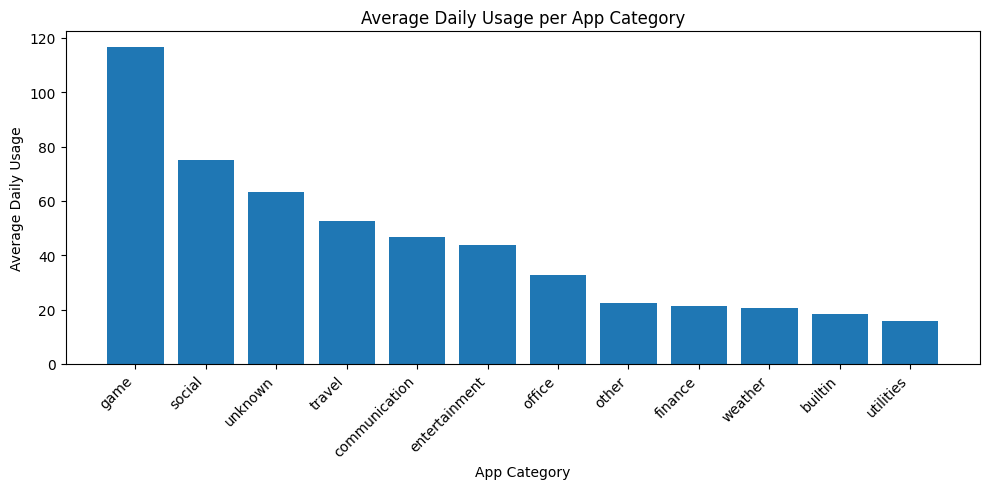

In [53]:
app_avg = (
    df.filter(pl.col("variable").str.starts_with("appCat"))
    .group_by(["variable", "date"])
    .agg(pl.col("value").mean().alias("daily_avg"))
    .group_by("variable")
    .agg(pl.col("daily_avg").mean().alias("avg_daily_usage"))
    .sort("avg_daily_usage", descending=True)
)

labels = [v.replace("appCat.", "") for v in app_avg["variable"].to_list()]
values = app_avg["avg_daily_usage"].to_list()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(labels, values)
ax.set_xlabel("App Category")
ax.set_ylabel("Average Daily Usage")
ax.set_title("Average Daily Usage per App Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [62]:
def avg_by(group_col):
    return (
        app.group_by([group_col, "date"])
        .agg(pl.col("value").mean().alias("daily_avg"))
        .group_by(group_col)
        .agg(pl.col("daily_avg").mean().alias("avg_value"))
        .sort(group_col)
    )


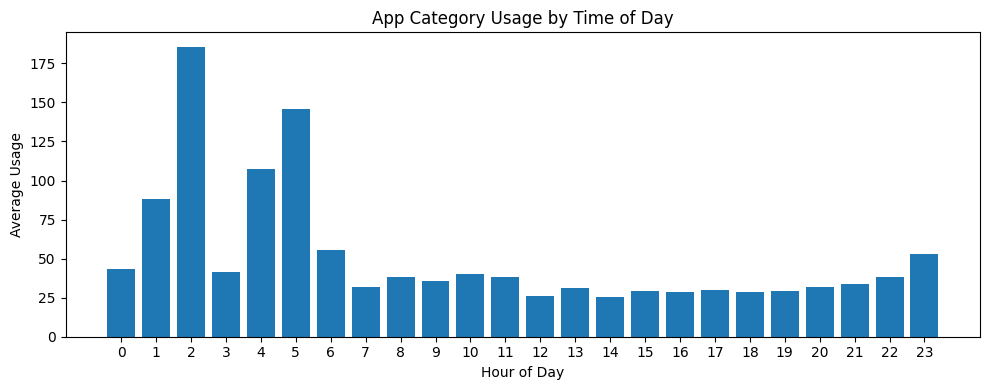

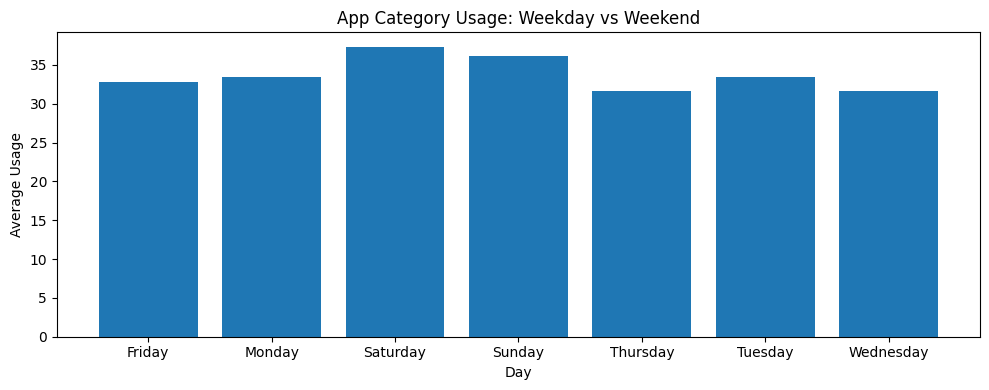

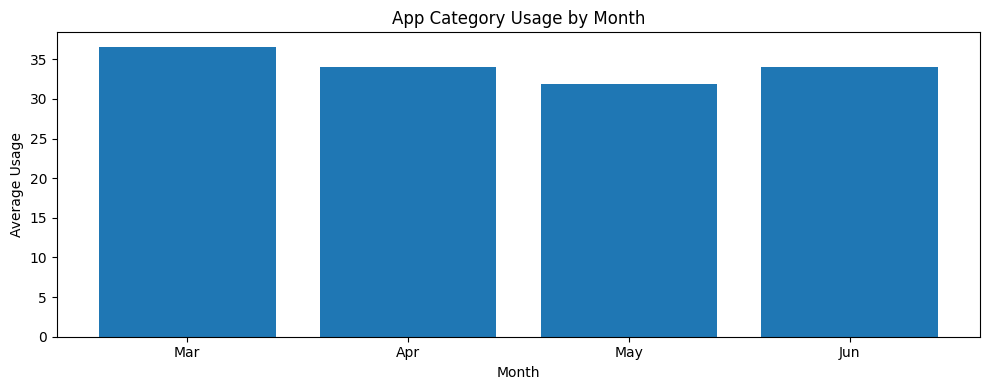

In [63]:

day_names = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

app = (
    df.filter(pl.col("variable").str.starts_with("appCat"))
    .with_columns(
        pl.col("time").dt.hour().alias("hour"),
        pl.col("date").dt.weekday().alias("weekday"),
        pl.col("date").dt.month().alias("month"),
    )
    .with_columns(
        pl.col("weekday").replace_strict(
            {i+1: name for i, name in enumerate(day_names)}
        ).alias("day_name")
    )
)

by_hour = avg_by("hour")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(by_hour["hour"].to_list(), by_hour["avg_value"].to_list())
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Usage")
ax.set_title("App Category Usage by Time of Day")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

by_daytype = avg_by("day_name")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(by_daytype["day_name"].to_list(), by_daytype["avg_value"].to_list())
ax.set_xlabel("Day")
ax.set_ylabel("Average Usage")
ax.set_title("App Category Usage: Weekday vs Weekend")
plt.tight_layout()
plt.show()

by_month = avg_by("month")
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
labels = [month_labels[m - 1] for m in by_month["month"].to_list()]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(labels, by_month["avg_value"].to_list())
ax.set_xlabel("Month")
ax.set_ylabel("Average Usage")
ax.set_title("App Category Usage by Month")
plt.tight_layout()
plt.show()